# Action / transition CDs (4 axes)

Build four coding-direction axes from the **previous-choice × upcoming-choice** 2×2 design, balanced at the cell level so each axis is orthogonalized w.r.t. the other factors.

| | Upcoming L | Upcoming R |
|---|---|---|
| **Prev L** | `L_L` (stay) | `switch_LR` |
| **Prev R** | `switch_RL` | `R_R` (stay) |

Per session we subsample the four cells to `n = min(|cell|)` trials, then fit four CDs:

| Axis | A (positive) | B (negative) |
|---|---|---|
| `prev_choice`  | Prev L (`L_L ∪ switch_LR`) | Prev R (`switch_RL ∪ R_R`) |
| `up_choice`    | Up L  (`L_L ∪ switch_RL`) | Up R  (`switch_LR ∪ R_R`) |
| `switch_stay`  | Switch (`switch_LR ∪ switch_RL`) | Stay (`L_L ∪ R_R`) |
| `switch_dir`   | `switch_LR` | `switch_RL` |

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"Modules loaded from: {MODULE_PATH}")

In [ ]:
# ALM recordings — sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13",
]

## 1. Build the 4 balanced action/transition CDs

`build_action_transition_cds` does it all per session:
  1. read the `L_L_trials`, `switch_LR_trials`, `switch_RL_trials`, `R_R_trials` columns from each behavior CSV,
  2. subsample each of those four cells to a common `n = min(…)` (deterministic with `seed`),
  3. write the balanced cells *and* the four axis unions back into the CSV as new `*_balanced_trials` columns,
  4. invoke `build_cd_dataset` once per axis so you get four CD zarrs per session/region/window.

In [ ]:
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import (
    build_action_transition_cds,
    ACTION_AXES,
)

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

align                  = "go_cue"
binsize                = "0.1"
brain_regions_groups   = [[]]              # [[]] => all units
time_windows           = [(-1, 0)]          # CD-fitting window (pre-go_cue)
min_units_num          = 30
projection_time_window = None
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True
balance_seed           = 0   # seed for per-session 4-cell subsample
balance_suffix         = "balanced"

failed, counts = build_action_transition_cds(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,
    seed=balance_seed,
    suffix=balance_suffix,
    n_per_cell=None,                    # use min across cells per session
    axes=tuple(ACTION_AXES.keys()),     # all four
    overwrite_columns=True,             # rewrite CSV columns
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
)
print("Failed items:", failed)
print("Per-session balanced counts:", counts)

## 2. Visualize each axis per session

For every session, plot the standard 3-panel CD figure for each of the 4 axes. The CD zarr filenames carry the axis-specific column pair, so we just rebuild the path with `cd_save_path` for each axis.

In [ ]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path,
    load_cd_session,
    plot_cd_session,
    region_label,
    ACTION_AXES,
)

viz_region_group     = []
viz_time_window      = (-1, 0)
distribution_window  = (-1, 0)
restrict_events      = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)

# Column-name pairs that `_balance_action_cells` writes (must match the seed/suffix above).
axis_column_pairs = {
    "prev_choice":   (f"prev_L_{balance_suffix}_trials",   f"prev_R_{balance_suffix}_trials"),
    "up_choice":     (f"up_L_{balance_suffix}_trials",     f"up_R_{balance_suffix}_trials"),
    "switch_stay":   (f"switch_{balance_suffix}_trials",   f"stay_{balance_suffix}_trials"),
    "switch_dir":    (f"switch_LR_{balance_suffix}_trials", f"switch_RL_{balance_suffix}_trials"),
}

for session in sessions:
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV missing for {session}")
        continue
    print(f"\n=========== Session: {session} ===========")
    for axis, cols in axis_column_pairs.items():
        zpath = cd_save_path(
            cd_root, session, region_lbl, cols, viz_time_window, align=align,
        )
        if not zpath.exists():
            print(f"  [skip] {axis}: zarr not built ({zpath.name})")
            continue
        sess = load_cd_session(zpath, beh_csv)
        print(f"  --- axis = {axis} ({cols[0]} vs {cols[1]}) ---")
        plot_cd_session(
            sess,
            distribution_window=distribution_window,
            restrict_events=restrict_events,
            restrict_align=align,
            xlim=(-15, 5),
            split="test",
            smooth_gauss=0.0,
            smooth_moving_window=10,
            plot_single_trial=True,
            random_sample_trial_N=5,
        )

## 3. Project all 4 cells onto each axis

For each axis, project the four 2×2 cells (`L_L`, `switch_LR`, `switch_RL`, `R_R`) onto its CD axis. `plot_cd_session(trial_types=...)` accepts at most 2 columns at a time, so we render two figures per axis — one for stays (`L_L` vs `R_R`) and one for switches (`switch_LR` vs `switch_RL`) — together covering all four cells.

Reading the result: on the `prev_choice` axis, prev-L cells (`L_L`, `switch_LR`) should separate from prev-R cells (`switch_RL`, `R_R`) regardless of upcoming choice; on `up_choice`, the split should follow the upcoming side; etc.

In [ ]:
# Pairs of cells to overlay per axis (need 1 or 2 cols per plot_cd_session call)
cell_pairs = [
    (f"L_L_{balance_suffix}_trials",       f"R_R_{balance_suffix}_trials"),        # stays
    (f"switch_LR_{balance_suffix}_trials", f"switch_RL_{balance_suffix}_trials"),  # switches
]

for session in sessions:
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        continue
    print(f"\n=========== Session: {session} ===========")
    for axis, cols in axis_column_pairs.items():
        zpath = cd_save_path(
            cd_root, session, region_lbl, cols, viz_time_window, align=align,
        )
        if not zpath.exists():
            continue
        sess = load_cd_session(zpath, beh_csv)
        for pair_name, pair_cols in zip(("stays", "switches"), cell_pairs):
            print(f"  axis = {axis} | {pair_name}: {pair_cols[0]} vs {pair_cols[1]}")
            plot_cd_session(
                sess,
                distribution_window=distribution_window,
                restrict_events=restrict_events,
                restrict_align=align,
                xlim=(-15, 5),
                split="test",
                smooth_gauss=0.0,
                smooth_moving_window=10,
                plot_single_trial=True,
                random_sample_trial_N=5,
                trial_types=list(pair_cols),
            )

## 4. Decode trial types from the CD projection

For every axis, fit a 1D **decision boundary** on the train-fold projections (averaged over the decoding window) and evaluate it on the **held-out test** trials. We use the balanced-accuracy-optimal threshold and report:

- training & test accuracy + balanced accuracy
- ROC curve + AUC on test trials
- 2x2 confusion matrix
- accuracy & AUC as a function of time (sliding window) so you can see *when* each variable becomes decodable.

In [ ]:
from ephys_dimension_reduction_CD_pipeline import (
    decode_cd_session,
    plot_cd_decoder,
)

# Window over which to average the projection trace into one scalar/trial.
decode_window = (-1.0, 0.0)          # same as CD-fitting window
decode_method = "optimal"             # "optimal" | "midpoint"
time_curve_bin = 0.2                  # sliding decoder window (s)

# Collect per-axis / per-session accuracy for the summary plot.
import pandas as pd
decode_rows = []

for session in sessions:
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        continue
    print(f"\n=========== Session: {session} ===========")
    for axis, cols in axis_column_pairs.items():
        zpath = cd_save_path(
            cd_root, session, region_lbl, cols, viz_time_window, align=align,
        )
        if not zpath.exists():
            continue
        sess = load_cd_session(zpath, beh_csv)
        print(f"  --- axis = {axis} ({cols[0]} vs {cols[1]}) ---")
        result = plot_cd_decoder(
            sess,
            window=decode_window,
            method=decode_method,
            show_time_curve=True,
            time_curve_bin=time_curve_bin,
        )
        decode_rows.append({
            "session": session,
            "axis": axis,
            "boundary": result.boundary,
            "train_acc": result.train_accuracy,
            "test_acc": result.test_accuracy,
            "train_bal_acc": result.train_balanced_accuracy,
            "test_bal_acc": result.test_balanced_accuracy,
            "test_auc": result.test_auc,
            "n_test_A": int(result.test_scores_a.size),
            "n_test_B": int(result.test_scores_b.size),
        })

decode_df = pd.DataFrame(decode_rows)
decode_df

### Summary across sessions

Bar plot of the test accuracy & AUC per axis (dots = individual sessions, bar = mean).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if len(decode_df):
    axes_order = list(axis_column_pairs.keys())
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
    for ax, metric, ylabel in zip(
        axs,
        ("test_bal_acc", "test_auc"),
        ("Test balanced accuracy", "Test AUC"),
    ):
        xs = np.arange(len(axes_order))
        means = [decode_df.loc[decode_df.axis == a, metric].mean() for a in axes_order]
        ax.bar(xs, means, color="tab:gray", alpha=0.6, edgecolor="k")
        for i, a in enumerate(axes_order):
            vals = decode_df.loc[decode_df.axis == a, metric].values
            jitter = (np.random.default_rng(0).uniform(-0.15, 0.15, size=vals.size))
            ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
                       color="tab:blue", s=40, edgecolor="k", zorder=3)
        ax.axhline(0.5, color="red", linestyle=":", lw=1, label="chance")
        ax.set_xticks(xs)
        ax.set_xticklabels(axes_order, rotation=15, ha="right")
        ax.set_ylim(0.3, 1.0)
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=9)
    fig.suptitle("CD decoder — per-axis test performance (each dot = session)")
    fig.tight_layout()
    plt.show()
else:
    print("No decoder results to summarize.")

## 5. Time-resolved decoding (CD re-fit per time bin)

For every time bin (centered at `c`, width `bin_window`):

1. Find trials whose `[restrict_events[0], restrict_events[1]]` interval (offsets
   relative to `restrict_align`) fully covers `[c - bin_window/2, c + bin_window/2]`.
2. Intersect the 4 action cells (`L_L`, `switch_LR`, `switch_RL`, `R_R`) with this
   eligible set and subsample each to `n = min(...)` ? so all four axes stay
   balanced w.r.t. the orthogonal factors at this bin.
3. Fit a fresh CD axis for each axis on the balanced cell unions, using only this
   bin's data window, and decode the held-out trials with a 1D threshold.

The result is one accuracy / AUC curve per axis. The drop near long pre-trial
times reflects fewer eligible trials (some sessions have shorter ITIs); the
secondary axis shows the minimum balanced sample size per bin across sessions.


In [39]:
from ephys_dimension_reduction_CD_pipeline import (
    decode_action_axes_over_time,
    plot_action_decoding_over_time,
)
import numpy as np
import json
import pandas as pd
from pathlib import Path

# Time-bin grid (relative to PSTH ``align``, here go_cue)
tr_t_start = -4
tr_t_end   =  5
tr_step    =  0.1     # how often to fit a new CD axis
tr_window  =  0.2     # width of each CD-fit + decoding window

# Trial eligibility: only use trials whose [trial_start, go_cue] covers the bin
tr_restrict_events = ("previous_trial_go_cue", "trial_end")
tr_restrict_align  = "previous_trial_go_cue"
align="trial_start"


tr_df = decode_action_axes_over_time(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    metadata=None,                # all units
    binsize=binsize,
    align=align,
    t_start=tr_t_start,
    t_end=tr_t_end,
    bin_step=tr_step,
    bin_window=tr_window,
    restrict_events=tr_restrict_events,
    restrict_align=tr_restrict_align,
    axes=("prev_choice", "up_choice", "switch_stay", "switch_dir"),
    region_group=(),
    min_units_num=min_units_num,
    n_per_cell=None,              # auto = min across cells per bin
    seed=0,
    norm_mode=norm_mode,
    decoder_method="optimal",
    two_fold_cv=True,
    random_state=random_state,
    verbose=True,
)

# --- Save tr_df + metadata so the visualization cell can reload it ---
decode_save_dir = Path("/root/capsule/scratch/CD_results/decoder_over_time")
decode_save_dir.mkdir(parents=True, exist_ok=True)
decode_tag = (
    f"ALM_align-{align}"
    f"_t{tr_t_start:+.1f}to{tr_t_end:+.1f}"
    f"_step{tr_step}_win{tr_window}"
    f"_restrict-{tr_restrict_events[0]}-{tr_restrict_events[1]}"
    f"_seed0"
)
df_path   = decode_save_dir / f"tr_df_{decode_tag}.parquet"
csv_path  = decode_save_dir / f"tr_df_{decode_tag}.csv"
meta_path = decode_save_dir / f"tr_df_{decode_tag}.meta.json"
try:
    tr_df.to_parquet(df_path, index=False)
    print(f"Saved parquet: {df_path}")
except Exception as e:
    print(f"[warn] parquet save failed ({e}); CSV only.")
tr_df.to_csv(csv_path, index=False)
print(f"Saved CSV    : {csv_path}")
meta = {
    "tag": decode_tag,
    "sessions": list(sessions),
    "align": align,
    "binsize": binsize,
    "t_start": tr_t_start,
    "t_end": tr_t_end,
    "bin_step": tr_step,
    "bin_window": tr_window,
    "restrict_events": list(tr_restrict_events),
    "restrict_align": tr_restrict_align,
    "axes": ["prev_choice", "up_choice", "switch_stay", "switch_dir"],
    "region_group": [],
    "min_units_num": min_units_num,
    "n_per_cell": None,
    "seed": 0,
    "norm_mode": norm_mode,
    "decoder_method": "optimal",
    "two_fold_cv": True,
    "random_state": random_state,
    "n_rows": int(len(tr_df)),
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Saved meta   : {meta_path}")

tr_df.head()



=== ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 (region=RG_ALL) ===
  units=ALL
  [info] restrict_align='previous_trial_go_cue' differs from PSTH align='trial_start'; using PSTH align for eligibility frame.
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
    bin -3.100s done (n_per_cell=72, eligible=538)
    bin -2.200s done (n_per_cell=72, eligible=538)
    bin -1.300s done (n_per_cell=72, eligible=538)
    bin -0.400s done (n_per_cell=72, eligible=538)
    bin +0.500s done (n_per_cell=72, eligible=538)
    bin +1.400s done (n_per_cell=72, eligible=538)
    bin +2.300s done (n_per_cell=72, eligible=538)
    bin +3.200s done (n_per_cell=72, eligible=538)
    bin +4.100s done (n_per_cell=72, eligible=538)
    bin +5.000s done (n_per_cell=72, eligible=537)

=== ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 (region=RG_ALL

/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:654: RuntimeWarning: Mean of empty slice
  (np.nanmean(y_pos) - np.nanmean(y_neg))
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:655: RuntimeWarning: Degrees of freedom <= 0 for slice.
  / (np.sqrt(0.5 * (np.nanvar(y_pos) + np.nanvar(y_neg))) + 1e-12)


    bin -3.100s done (n_per_cell=56, eligible=517)
    bin -2.200s done (n_per_cell=56, eligible=517)
    bin -1.300s done (n_per_cell=56, eligible=517)
    bin -0.400s done (n_per_cell=56, eligible=517)
    bin +0.500s done (n_per_cell=56, eligible=517)
    bin +1.400s done (n_per_cell=56, eligible=517)
    bin +2.300s done (n_per_cell=56, eligible=517)
    bin +3.200s done (n_per_cell=56, eligible=517)
    bin +4.100s done (n_per_cell=56, eligible=517)
    bin +5.000s done (n_per_cell=56, eligible=516)

=== ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 (region=RG_ALL) ===
  units=ALL
  [info] restrict_align='previous_trial_go_cue' differs from PSTH align='trial_start'; using PSTH align for eligibility frame.
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:654: RuntimeWarning: Mean of empty slice
  (np.nanmean(y_pos) - np.nanmean(y_neg))
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:655: RuntimeWarning: Degrees of freedom <= 0 for slice.
  / (np.sqrt(0.5 * (np.nanvar(y_pos) + np.nanvar(y_neg))) + 1e-12)


    bin -3.100s done (n_per_cell=48, eligible=538)
    bin -2.200s done (n_per_cell=48, eligible=538)
    bin -1.300s done (n_per_cell=48, eligible=538)
    bin -0.400s done (n_per_cell=48, eligible=538)
    bin +0.500s done (n_per_cell=48, eligible=538)
    bin +1.400s done (n_per_cell=48, eligible=538)
    bin +2.300s done (n_per_cell=48, eligible=538)
    bin +3.200s done (n_per_cell=48, eligible=538)
    bin +4.100s done (n_per_cell=48, eligible=538)
    bin +5.000s done (n_per_cell=48, eligible=538)

=== ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 (region=RG_ALL) ===
  units=ALL
  [info] restrict_align='previous_trial_go_cue' differs from PSTH align='trial_start'; using PSTH align for eligibility frame.
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:654: RuntimeWarning: Mean of empty slice
  (np.nanmean(y_pos) - np.nanmean(y_neg))
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD.py:655: RuntimeWarning: Degrees of freedom <= 0 for slice.
  / (np.sqrt(0.5 * (np.nanvar(y_pos) + np.nanvar(y_neg))) + 1e-12)


    bin -3.100s done (n_per_cell=14, eligible=502)
    bin -2.200s done (n_per_cell=14, eligible=502)
    bin -1.300s done (n_per_cell=14, eligible=502)
    bin -0.400s done (n_per_cell=14, eligible=502)
    bin +0.500s done (n_per_cell=14, eligible=502)
    bin +1.400s done (n_per_cell=14, eligible=502)
    bin +2.300s done (n_per_cell=14, eligible=502)
    bin +3.200s done (n_per_cell=14, eligible=502)
    bin +4.100s done (n_per_cell=14, eligible=502)
    bin +5.000s done (n_per_cell=14, eligible=502)

=== ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 (region=RG_ALL) ===
  units=ALL
  [info] restrict_align='previous_trial_go_cue' differs from PSTH align='trial_start'; using PSTH align for eligibility frame.
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
    bin -3.100s done (n_per_cell=17, eligible=500)
    bin -2.200s done (n_per_ce

,session,axis,center,n_per_cell,n_eligible,train_acc,test_acc,train_bal_acc,test_bal_acc,test_auc,boundary,sign
0,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_choice,-4.0,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0
1,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,up_choice,-4.0,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0
2,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,switch_stay,-4.0,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0
3,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,switch_dir,-4.0,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0
4,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_choice,-3.9,0,8,NaN,NaN,NaN,NaN,NaN,NaN,0


Loaded CSV    : /root/capsule/scratch/CD_results/decoder_over_time/tr_df_ALM_align-trial_start_t-4.0to+5.0_step0.1_win0.2_restrict-previous_trial_go_cue-trial_end_seed0.csv  (2184 rows)
Run metadata:
  tag: ALM_align-trial_start_t-4.0to+5.0_step0.1_win0.2_restrict-previous_trial_go_cue-trial_end_seed0
  sessions: ['ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38', 'ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35', 'ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43', 'ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45', 'ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51', 'ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13']
  align: trial_start
  binsize: 0.1
  t_start: -4
  t_end: 5
  bin_step: 0.1
  bin_window: 0.2
  restrict_events: ['previous_trial_go_cue', 'trial_end']
  restrict_align: previous_trial_go_cue
  axes: ['prev_choice', 'up_choice', 'switch_stay', 'switch_dir']
  region_group: []
  min_units_num:

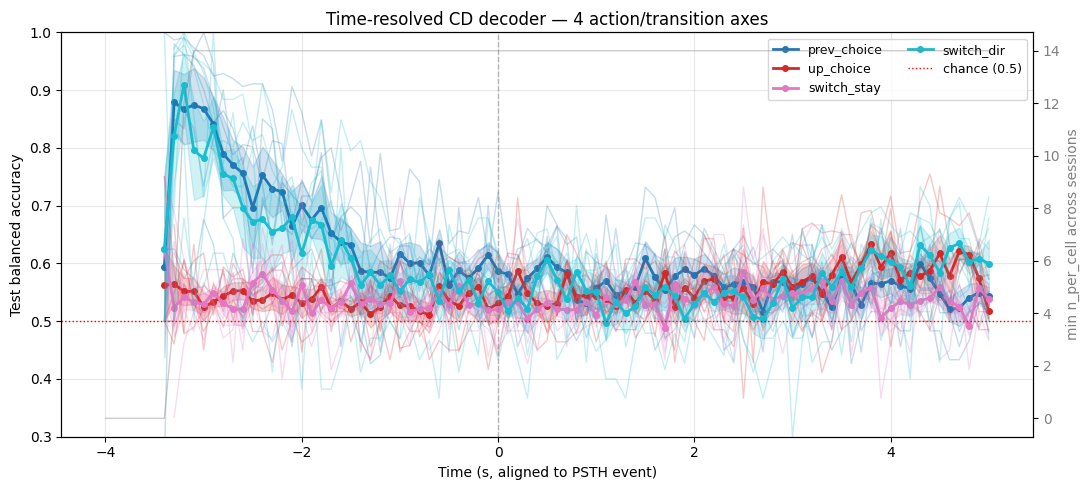

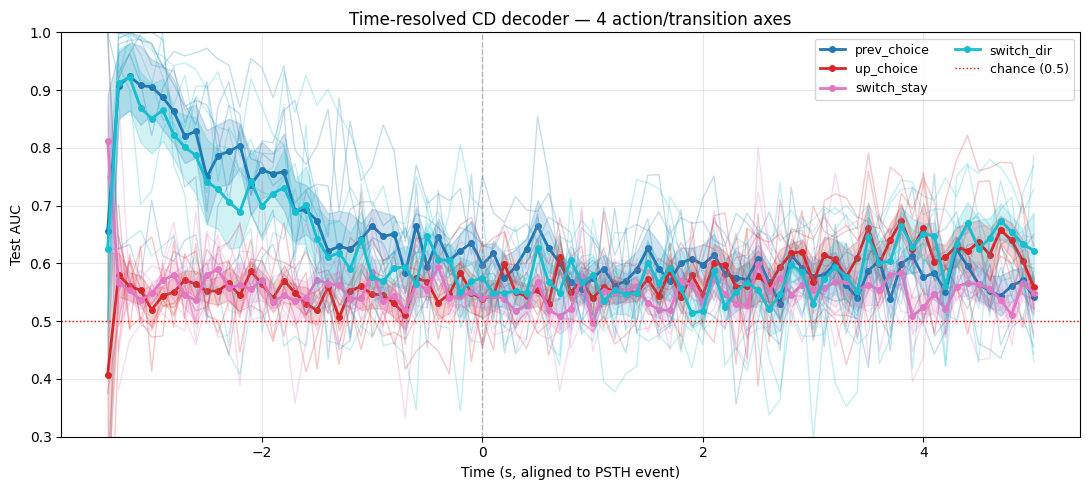

In [40]:
# Load tr_df from disk, then plot. Lets you run this cell standalone after a
# kernel restart (no need to re-run the slow decoder cell above).
import json
import pandas as pd
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import plot_action_decoding_over_time

decode_save_dir = Path("/root/capsule/scratch/CD_results/decoder_over_time")

# Use the tag produced by the cell above (when run in the same kernel).
# Otherwise auto-load the most recently modified tr_df_* file.
try:
    load_tag = decode_tag  # noqa: F821
except NameError:
    load_tag = None

if load_tag is None:
    candidates = sorted(decode_save_dir.glob("tr_df_*.parquet")) \
              or sorted(decode_save_dir.glob("tr_df_*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No saved tr_df_* files found in {decode_save_dir}")
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    load_tag = latest.stem.replace("tr_df_", "").rsplit(".", 1)[0]
    print(f"[auto] no load_tag set; loading most recent: {load_tag}")

df_path   = decode_save_dir / f"tr_df_{load_tag}.parquet"
csv_path  = decode_save_dir / f"tr_df_{load_tag}.csv"
meta_path = decode_save_dir / f"tr_df_{load_tag}.meta.json"

if df_path.exists():
    tr_df = pd.read_parquet(df_path)
    print(f"Loaded parquet: {df_path}  ({len(tr_df)} rows)")
elif csv_path.exists():
    tr_df = pd.read_csv(csv_path)
    print(f"Loaded CSV    : {csv_path}  ({len(tr_df)} rows)")
else:
    raise FileNotFoundError(f"No saved tr_df found for tag {load_tag!r}")

if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    print("Run metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

# ----- Plots -----
# Mean +/- SEM across sessions
plot_action_decoding_over_time(
    tr_df, metric="test_bal_acc", aggregate="sessions", show_n=True,
)

# Per-session thin lines + group mean
plot_action_decoding_over_time(
    tr_df, metric="test_auc", aggregate="sessions", show_n=False,
)


## 6. Time-resolved decoding of *previous-trial reward*

Independent 2-cell design:

| Cell | Members |
|---|---|
| `prev_rewarded`   | trials where the **previous** trial was rewarded (`rewarded_historyL[i-1] ∨ rewarded_historyR[i-1]`) |
| `prev_unrewarded` | trials where the previous trial was not rewarded |

Membership is computed from the NWB on the fly (no behavior CSV needed). Per
bin we apply the same eligibility filter and balance the two cells to a common
count, so the reported accuracy / AUC reflects a balanced 2-class decoder of
"was the last trial rewarded?".

In [35]:
from ephys_dimension_reduction_CD_pipeline import (
    decode_prev_reward_over_time,
    plot_action_decoding_over_time,
)
import numpy as np
import json
import pandas as pd
from pathlib import Path

# Reuse the bin grid and eligibility settings from Section 5 (override below if you want).
pr_t_start = -3
pr_t_end   = 8
pr_step    = tr_step
pr_window  = tr_window
pr_restrict_events = ("previous_trial_go_cue", "trial_end")
pr_restrict_align  = "previous_trial_go_cue"
pr_align           = align

pr_df = decode_prev_reward_over_time(
    sessions=sessions,
    psth_root=psth_root,
    metadata=None,                # all units
    binsize=binsize,
    align=pr_align,
    t_start=pr_t_start,
    t_end=pr_t_end,
    bin_step=pr_step,
    bin_window=pr_window,
    restrict_events=pr_restrict_events,
    restrict_align=pr_restrict_align,
    region_group=(),
    min_units_num=min_units_num,
    n_per_cell=None,              # auto = min across cells per bin
    seed=0,
    norm_mode=norm_mode,
    decoder_method="optimal",
    two_fold_cv=True,
    random_state=random_state,
    verbose=True,
)

# --- Save pr_df + metadata ---
decode_save_dir = Path("/root/capsule/scratch/CD_results/decoder_over_time")
decode_save_dir.mkdir(parents=True, exist_ok=True)
pr_tag = (
    f"PREVREWARD_ALM_align-{pr_align}"
    f"_t{pr_t_start:+.1f}to{pr_t_end:+.1f}"
    f"_step{pr_step}_win{pr_window}"
    f"_restrict-{pr_restrict_events[0]}-{pr_restrict_events[1]}"
    f"_seed0"
)
pr_df_path   = decode_save_dir / f"pr_df_{pr_tag}.parquet"
pr_csv_path  = decode_save_dir / f"pr_df_{pr_tag}.csv"
pr_meta_path = decode_save_dir / f"pr_df_{pr_tag}.meta.json"
try:
    pr_df.to_parquet(pr_df_path, index=False)
    print(f"Saved parquet: {pr_df_path}")
except Exception as e:
    print(f"[warn] parquet save failed ({e}); CSV only.")
pr_df.to_csv(pr_csv_path, index=False)
print(f"Saved CSV    : {pr_csv_path}")
pr_meta = {
    "tag": pr_tag,
    "sessions": list(sessions),
    "align": pr_align,
    "binsize": binsize,
    "t_start": pr_t_start,
    "t_end": pr_t_end,
    "bin_step": pr_step,
    "bin_window": pr_window,
    "restrict_events": list(pr_restrict_events),
    "restrict_align": pr_restrict_align,
    "axes": ["prev_reward"],
    "region_group": [],
    "min_units_num": min_units_num,
    "n_per_cell": None,
    "seed": 0,
    "norm_mode": norm_mode,
    "decoder_method": "optimal",
    "two_fold_cv": True,
    "random_state": random_state,
    "n_rows": int(len(pr_df)),
}
with open(pr_meta_path, "w") as f:
    json.dump(pr_meta, f, indent=2)
print(f"Saved meta   : {pr_meta_path}")

# Quick eligibility diagnostic — where does balanced n start to die?
print("\nEligibility / balanced n per bin (min across sessions):")
print(pr_df.groupby("center")[["n_eligible", "n_per_cell"]].min().to_string())

pr_df.head()



=========== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===========
  units=411
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
  [info] restrict_align='previous_trial_go_cue' differs from PSTH align='trial_start'; using PSTH align for eligibility frame.
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
    bin -3.000s done (n_per_cell=267, eligible=538)
    bin -1.900s done (n_per_cell=267, eligible=538)
    bin -0.800s done (n_per_cell=267, eligible=538)
    bin +0.300s done (n_per_cell=267, eligible=538)
    bin +1.400s done (n_per_cell=267, eligible=538)
    bin +2.500s done (n_per_cell=267, eligible=538)
    bin +3.600s done (n_per_cell=267, eligible=538)
    bin +4.700s done (n_per_cell=26

,session,axis,center,n_per_cell,n_eligible,train_acc,test_acc,train_bal_acc,test_bal_acc,test_auc,boundary,sign
0,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_reward,-3.0,267,538,0.943820,0.908240,0.943820,0.908240,0.979562,0.464310,1
1,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_reward,-2.9,267,538,0.975655,0.962547,0.975655,0.962547,0.993856,-0.313595,1
2,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_reward,-2.8,267,538,0.951311,0.953184,0.951311,0.953184,0.982943,-0.199944,1
3,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_reward,-2.7,267,538,0.955056,0.941948,0.955056,0.941948,0.979043,-0.473728,1
4,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,prev_reward,-2.6,267,538,0.951311,0.945693,0.951311,0.945693,0.977149,0.343544,1


Loaded CSV    : /root/capsule/scratch/CD_results/decoder_over_time/pr_df_PREVREWARD_ALM_align-trial_start_t-3.0to+8.0_step0.1_win0.2_restrict-previous_trial_go_cue-trial_end_seed0.csv  (666 rows)
Run metadata:
  tag: PREVREWARD_ALM_align-trial_start_t-3.0to+8.0_step0.1_win0.2_restrict-previous_trial_go_cue-trial_end_seed0
  sessions: ['ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38', 'ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35', 'ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43', 'ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45', 'ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51', 'ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13']
  align: trial_start
  binsize: 0.1
  t_start: -3
  t_end: 8
  bin_step: 0.1
  bin_window: 0.2
  restrict_events: ['previous_trial_go_cue', 'trial_end']
  restrict_align: previous_trial_go_cue
  axes: ['prev_reward']
  region_group: []
  min_units_num: 30
  n_per_cell: Non

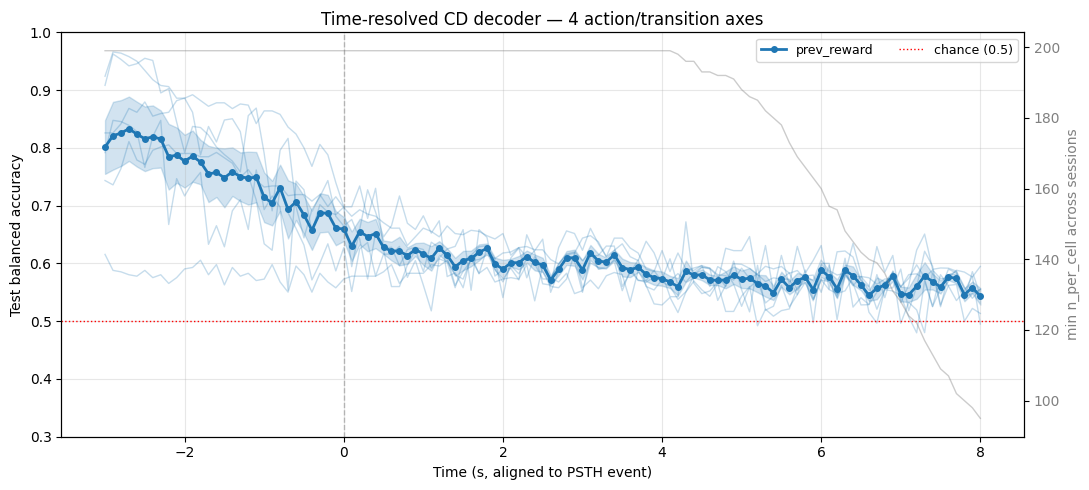

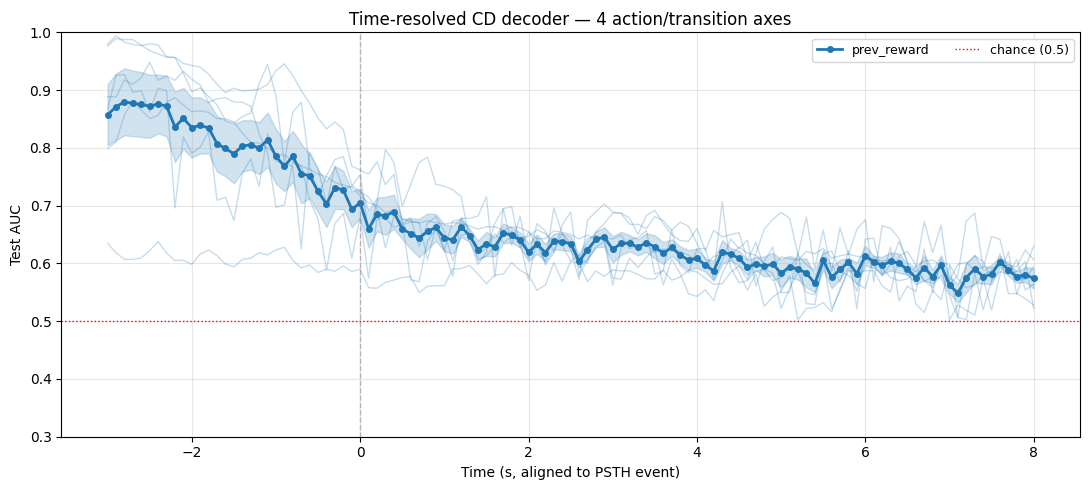

In [36]:
# Load pr_df from disk, then plot. Standalone after kernel restart.
import json
import pandas as pd
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import plot_action_decoding_over_time

decode_save_dir = Path("/root/capsule/scratch/CD_results/decoder_over_time")

try:
    pr_load_tag = pr_tag  # noqa: F821
except NameError:
    pr_load_tag = None

if pr_load_tag is None:
    candidates = sorted(decode_save_dir.glob("pr_df_*.parquet")) \
              or sorted(decode_save_dir.glob("pr_df_*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No saved pr_df_* files found in {decode_save_dir}")
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    pr_load_tag = latest.stem.replace("pr_df_", "").rsplit(".", 1)[0]
    print(f"[auto] no pr_load_tag set; loading most recent: {pr_load_tag}")

pr_df_path   = decode_save_dir / f"pr_df_{pr_load_tag}.parquet"
pr_csv_path  = decode_save_dir / f"pr_df_{pr_load_tag}.csv"
pr_meta_path = decode_save_dir / f"pr_df_{pr_load_tag}.meta.json"

if pr_df_path.exists():
    pr_df = pd.read_parquet(pr_df_path)
    print(f"Loaded parquet: {pr_df_path}  ({len(pr_df)} rows)")
elif pr_csv_path.exists():
    pr_df = pd.read_csv(pr_csv_path)
    print(f"Loaded CSV    : {pr_csv_path}  ({len(pr_df)} rows)")
else:
    raise FileNotFoundError(f"No saved pr_df found for tag {pr_load_tag!r}")

if pr_meta_path.exists():
    with open(pr_meta_path) as f:
        pr_meta = json.load(f)
    print("Run metadata:")
    for k, v in pr_meta.items():
        print(f"  {k}: {v}")

# ----- Plots (reuse the action-axis plot helper; it draws one panel per axis,
# and pr_df contains only "prev_reward", so you get a single curve) -----
plot_action_decoding_over_time(
    pr_df, metric="test_bal_acc", aggregate="sessions", show_n=True,
)
plot_action_decoding_over_time(
    pr_df, metric="test_auc", aggregate="sessions", show_n=False,
)
